# FOLIO Two-Stage: Error Classification Analysis

Comprehensive analysis of 41 verified-but-wrong cases using error root cause classification.

Compares Two-Stage error patterns with simple Lean approach.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Define consistent color palette
ERROR_COLORS = {
    'AXIOMATIZES_CONCLUSION': '#e74c3c',
    'AXIOMATIZES_CONTRADICTION': '#3498db',
    'INCORRECT_FORMALIZATION': '#f39c12',
    'REASONING_FAILURE': '#2ecc71',
    'AXIOMATIZES_UNMENTIONED': '#9b59b6',
    'OTHER': '#95a5a6'
}

## 1. Load Data and Basic Statistics

In [7]:
# Load both Two-Stage and simple Lean data for comparison
df_ts = pd.read_csv('../../results/folio/two_stage/error_root_cause_analysis.csv')
df_lean = pd.read_csv('../../results/folio/lean/error_root_cause_analysis.csv')

print(f"Two-Stage cases: {len(df_ts)}")
print(f"Simple Lean cases: {len(df_lean)}")
print(f"Improvement: {len(df_lean) - len(df_ts)} fewer errors ({(len(df_lean)-len(df_ts))/len(df_lean)*100:.1f}% reduction)")
print(f"\nColumns: {list(df_ts.columns)}")

Two-Stage cases: 41
Simple Lean cases: 49
Improvement: 8 fewer errors (16.3% reduction)

Columns: ['Example_ID', 'Ground_Truth', 'Prediction', 'Pattern', 'Premises', 'Conclusion', 'Problematic_Lines', 'Root_Cause_Category', 'Error_Description', 'Specific_Axiom']


In [8]:
# Show first few rows
df_ts.head()

,Example_ID,Ground_Truth,Prediction,Pattern,Premises,Conclusion,Problematic_Lines,Root_Cause_Category,Error_Description,Specific_Axiom
0,1014,Unknown,True,Unknown → True,People in this club who perform in school tale...,Bonnie performs in school talent shows often.,line 27,AXIOMATIZES_CONCLUSION,The axiom 'bonnie_performs' directly asserts t...,axiom bonnie_performs : PerformsOften Bonnie
1,1208,Unknown,True,Unknown → True,All employees who schedule a meeting with thei...,James has lunch in the company.,line 28,AXIOMATIZES_CONCLUSION,The axiom A8 directly states that James has lu...,axiom A8 : LunchInCompany James
2,1209,Unknown,False,Unknown → False,All employees who schedule a meeting with thei...,James does not have lunch in the company.,line 47,AXIOMATIZES_CONCLUSION,The axiom 'James_not_lunch_in_company' directl...,axiom James_not_lunch_in_company : ¬ LunchInBu...
3,1210,True,Unknown,True → Unknown,All employees who schedule a meeting with thei...,If James is either a manager or in other count...,lines 64-66,AXIOMATIZES_CONCLUSION,The model 'worldFalse' directly contradicts th...,def worldFalse : Context := { ... Manager := f...
4,2,Unknown,True,Unknown → True,There are six types of wild turkeys: Eastern w...,Joey is a wild turkey.,line 30,AXIOMATIZES_CONCLUSION,The axiom W_Joey directly states that Joey is ...,axiom W_Joey : W Joey


## 2. Error Type Distribution

In [9]:
# Calculate error distribution for both approaches
ts_dist = df_ts['Root_Cause_Category'].value_counts()
lean_dist = df_lean['Root_Cause_Category'].value_counts()

print("Two-Stage vs Simple Lean:")
print("=" * 70)

all_categories = sorted(set(ts_dist.index) | set(lean_dist.index), 
                       key=lambda x: lean_dist.get(x, 0), reverse=True)

for category in all_categories:
    ts_count = ts_dist.get(category, 0)
    lean_count = lean_dist.get(category, 0)
    ts_pct = (ts_count / len(df_ts)) * 100
    lean_pct = (lean_count / len(df_lean)) * 100
    diff = lean_count - ts_count
    
    print(f"{category:30s}")
    print(f"  Simple Lean: {lean_count:3d} cases ({lean_pct:5.1f}%)")
    print(f"  Two-Stage:   {ts_count:3d} cases ({ts_pct:5.1f}%)")
    if diff > 0:
        print(f"  ✓ Two-Stage improved: {diff} fewer cases")
    elif diff < 0:
        print(f"  ✗ Two-Stage worse: {abs(diff)} more cases")
    else:
        print(f"  ~ Same performance")
    print()

# Calculate axiomatization totals
axiom_types = ['AXIOMATIZES_CONCLUSION', 'AXIOMATIZES_CONTRADICTION', 'AXIOMATIZES_UNMENTIONED']
ts_axiom = sum(ts_dist.get(t, 0) for t in axiom_types)
lean_axiom = sum(lean_dist.get(t, 0) for t in axiom_types)

print("=" * 70)
print(f"TOTAL AXIOMATIZATION ERRORS:")
print(f"  Simple Lean: {lean_axiom} cases ({lean_axiom/len(df_lean)*100:.1f}%)")
print(f"  Two-Stage:   {ts_axiom} cases ({ts_axiom/len(df_ts)*100:.1f}%)")
print(f"  Improvement: {lean_axiom - ts_axiom} cases ({(lean_axiom - ts_axiom)/lean_axiom*100:.1f}% reduction)")

Two-Stage vs Simple Lean:
AXIOMATIZES_CONCLUSION        
  Simple Lean:  29 cases ( 59.2%)
  Two-Stage:    20 cases ( 48.8%)
  ✓ Two-Stage improved: 9 fewer cases

AXIOMATIZES_CONTRADICTION     
  Simple Lean:   9 cases ( 18.4%)
  Two-Stage:     6 cases ( 14.6%)
  ✓ Two-Stage improved: 3 fewer cases

REASONING_FAILURE             
  Simple Lean:   7 cases ( 14.3%)
  Two-Stage:     7 cases ( 17.1%)
  ~ Same performance

INCORRECT_FORMALIZATION       
  Simple Lean:   4 cases (  8.2%)
  Two-Stage:     7 cases ( 17.1%)
  ✗ Two-Stage worse: 3 more cases

AXIOMATIZES_UNMENTIONED       
  Simple Lean:   0 cases (  0.0%)
  Two-Stage:     1 cases (  2.4%)
  ✗ Two-Stage worse: 1 more cases

TOTAL AXIOMATIZATION ERRORS:
  Simple Lean: 38 cases (77.6%)
  Two-Stage:   27 cases (65.9%)
  Improvement: 11 cases (28.9% reduction)


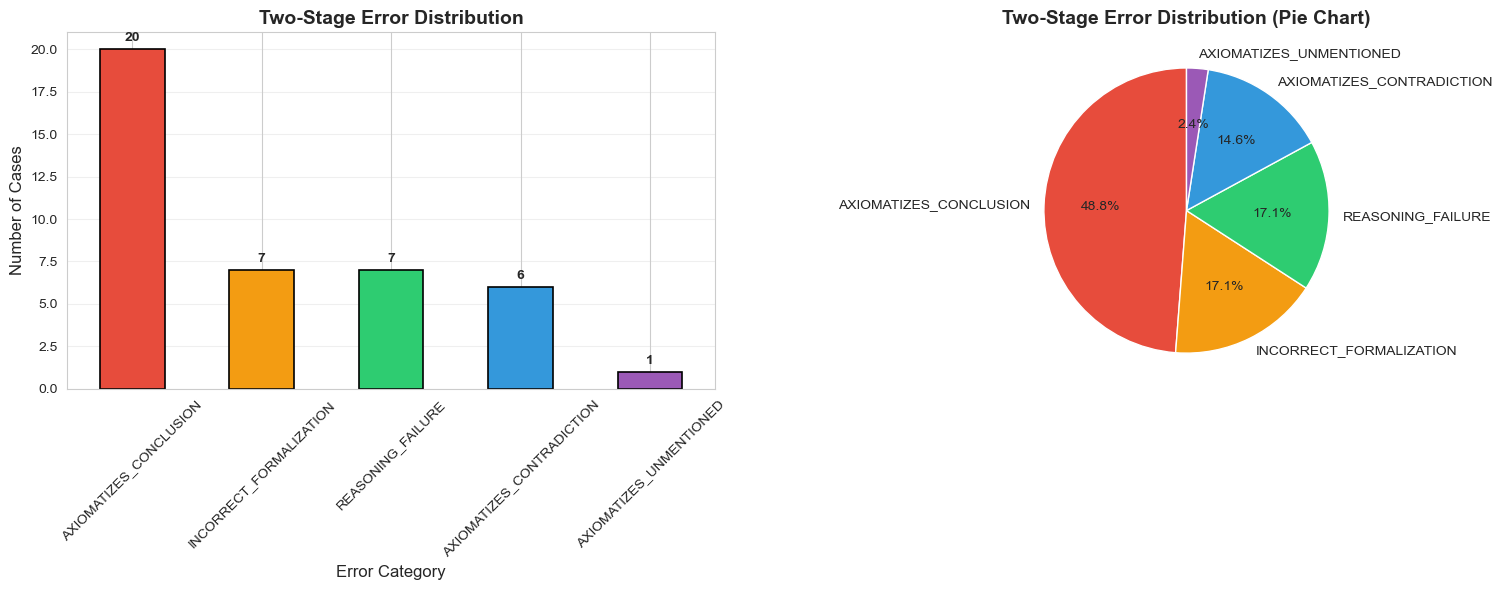

In [10]:
# Visualize error distribution comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Two-Stage
colors = [ERROR_COLORS.get(cat, '#95a5a6') for cat in ts_dist.index]
ts_dist.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_title('Two-Stage Error Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Error Category', fontsize=12)
ax1.set_ylabel('Number of Cases', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(ts_dist.values):
    ax1.text(i, v + 0.3, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors_pie = [ERROR_COLORS.get(cat, '#95a5a6') for cat in ts_dist.index]
ax2.pie(ts_dist.values, labels=ts_dist.index, autopct='%1.1f%%', 
        colors=colors_pie, startangle=90, textprops={'fontsize': 10})
ax2.set_title('Two-Stage Error Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

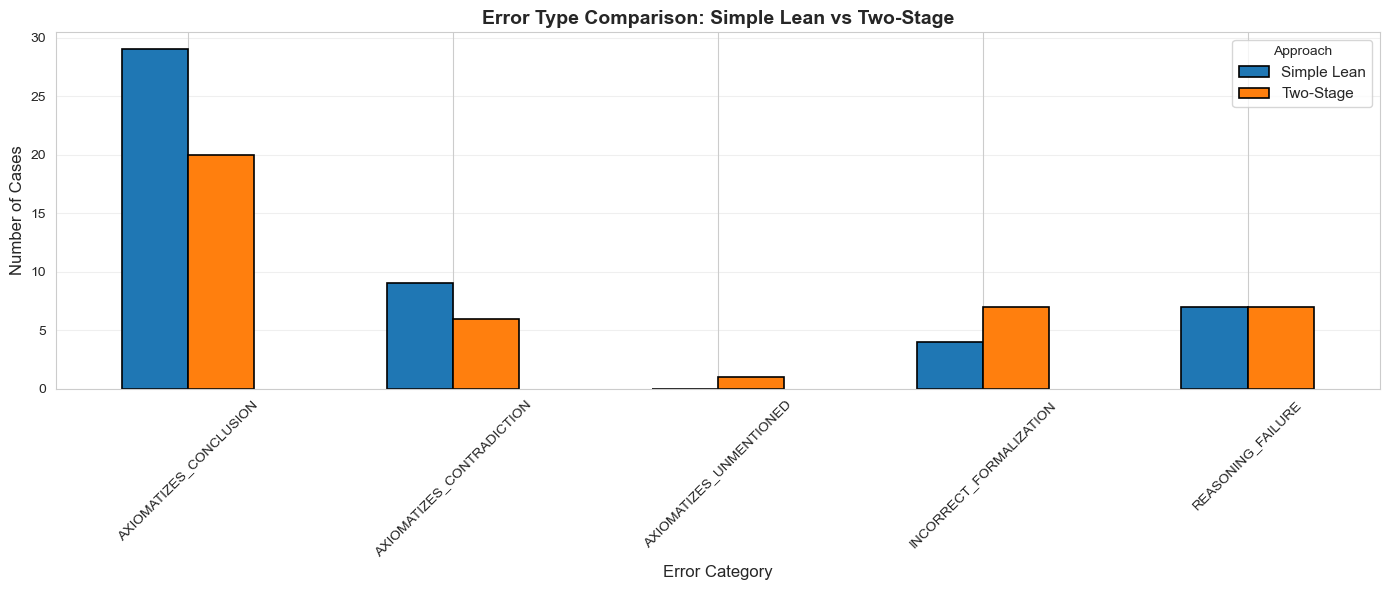

In [11]:
# Side-by-side comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Simple Lean': lean_dist,
    'Two-Stage': ts_dist
}).fillna(0)

comparison_df.plot(kind='bar', ax=ax, edgecolor='black', linewidth=1.2)
ax.set_title('Error Type Comparison: Simple Lean vs Two-Stage', fontsize=14, fontweight='bold')
ax.set_xlabel('Error Category', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.legend(title='Approach', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Error Types by Prediction Pattern

In [12]:
# Cross-tabulation for Two-Stage
pattern_error = pd.crosstab(df_ts['Pattern'], df_ts['Root_Cause_Category'])

print("Two-Stage Error Types by Pattern:")
print("=" * 70)
print(pattern_error)

print("\nKey insights:")
for pattern in pattern_error.index:
    top_error = pattern_error.loc[pattern].idxmax()
    count = pattern_error.loc[pattern].max()
    total = pattern_error.loc[pattern].sum()
    print(f"  {pattern} ({total} total): Most common is {top_error} ({count} cases)")

Two-Stage Error Types by Pattern:
Root_Cause_Category  AXIOMATIZES_CONCLUSION  AXIOMATIZES_CONTRADICTION  \
Pattern                                                                  
False → True                              2                          2   
False → Unknown                           4                          1   
True → False                              2                          0   
True → Unknown                            2                          1   
Unknown → False                           3                          0   
Unknown → True                            7                          2   

Root_Cause_Category  AXIOMATIZES_UNMENTIONED  INCORRECT_FORMALIZATION  \
Pattern                                                                 
False → True                               0                        0   
False → Unknown                            1                        1   
True → False                               0                        0   
True → U

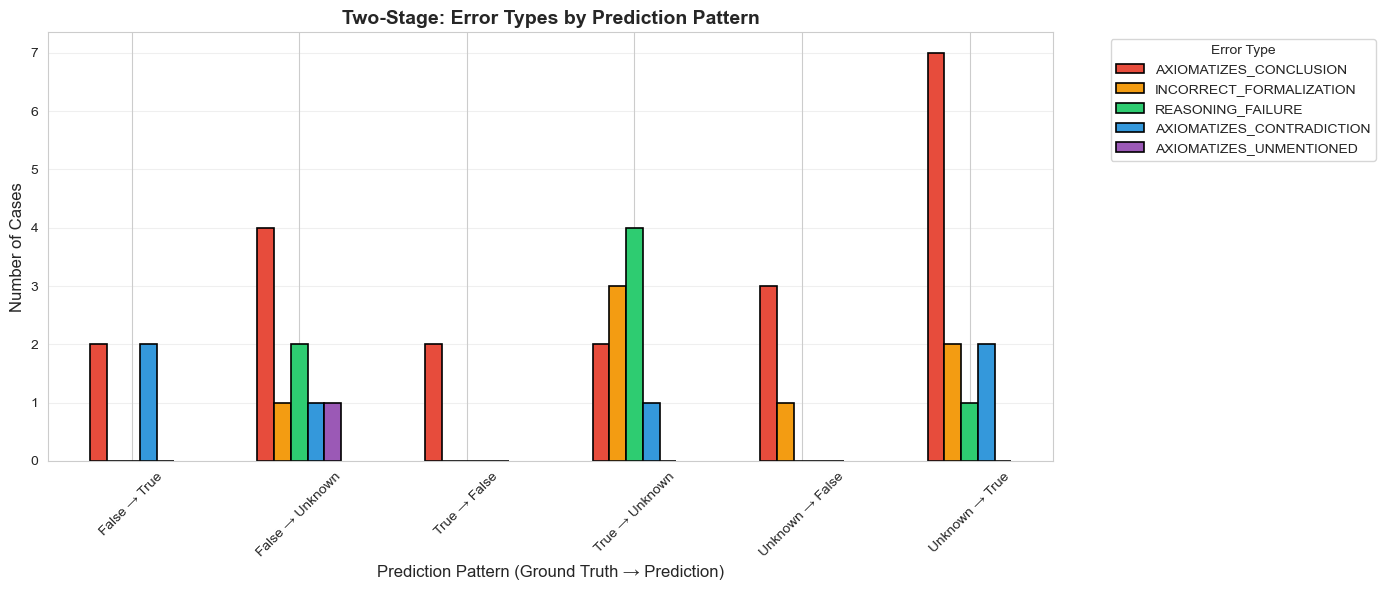

In [13]:
# Visualize grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Reorder columns by error type frequency
ordered_cols = ts_dist.index.tolist()
pattern_error_ordered = pattern_error[ordered_cols]

pattern_error_ordered.plot(kind='bar', ax=ax, 
                           color=[ERROR_COLORS.get(col, '#95a5a6') for col in ordered_cols],
                           edgecolor='black', linewidth=1.2)
ax.set_title('Two-Stage: Error Types by Prediction Pattern', fontsize=14, fontweight='bold')
ax.set_xlabel('Prediction Pattern (Ground Truth → Prediction)', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Key Findings

In [14]:
print("=" * 70)
print("KEY FINDINGS: FOLIO TWO-STAGE vs SIMPLE LEAN")
print("=" * 70)

print(f"\nOVERALL PERFORMANCE:")
print(f"  Simple Lean: {len(df_lean)} verified-but-wrong cases")
print(f"  Two-Stage:   {len(df_ts)} verified-but-wrong cases")
print(f"  ✓ Two-Stage reduces errors by {len(df_lean) - len(df_ts)} cases ({(len(df_lean)-len(df_ts))/len(df_lean)*100:.1f}%)")

print(f"\n1. AXIOMATIZATION ERRORS:")
print(f"   Simple Lean: {lean_axiom} cases ({lean_axiom/len(df_lean)*100:.1f}%)")
print(f"   Two-Stage:   {ts_axiom} cases ({ts_axiom/len(df_ts)*100:.1f}%)")
reduction_pct = (lean_axiom - ts_axiom) / lean_axiom * 100
print(f"   ✓ Two-Stage reduces axiomatization by {reduction_pct:.1f}%")

print(f"\n2. AXIOMATIZES_CONCLUSION:")
lean_ac = lean_dist.get('AXIOMATIZES_CONCLUSION', 0)
ts_ac = ts_dist.get('AXIOMATIZES_CONCLUSION', 0)
print(f"   Simple Lean: {lean_ac} cases ({lean_ac/len(df_lean)*100:.1f}%)")
print(f"   Two-Stage:   {ts_ac} cases ({ts_ac/len(df_ts)*100:.1f}%)")
print(f"   ✓ Slight improvement ({lean_ac - ts_ac} fewer cases)")

print(f"\n3. AXIOMATIZES_CONTRADICTION:")
lean_acontra = lean_dist.get('AXIOMATIZES_CONTRADICTION', 0)
ts_acontra = ts_dist.get('AXIOMATIZES_CONTRADICTION', 0)
print(f"   Simple Lean: {lean_acontra} cases ({lean_acontra/len(df_lean)*100:.1f}%)")
print(f"   Two-Stage:   {ts_acontra} cases ({ts_acontra/len(df_ts)*100:.1f}%)")
print(f"   ✓ Major improvement ({(lean_acontra-ts_acontra)/lean_acontra*100:.0f}% reduction!)")

print(f"\n4. INCORRECT_FORMALIZATION:")
lean_if = lean_dist.get('INCORRECT_FORMALIZATION', 0)
ts_if = ts_dist.get('INCORRECT_FORMALIZATION', 0)
print(f"   Simple Lean: {lean_if} cases ({lean_if/len(df_lean)*100:.1f}%)")
print(f"   Two-Stage:   {ts_if} cases ({ts_if/len(df_ts)*100:.1f}%)")
print(f"   ✗ Two-Stage has {ts_if/lean_if:.1f}x MORE formalization errors")

print(f"\n5. REASONING_FAILURE:")
lean_rf = lean_dist.get('REASONING_FAILURE', 0)
ts_rf = ts_dist.get('REASONING_FAILURE', 0)
print(f"   Simple Lean: {lean_rf} cases ({lean_rf/len(df_lean)*100:.1f}%)")
print(f"   Two-Stage:   {ts_rf} cases ({ts_rf/len(df_ts)*100:.1f}%)")
print(f"   ~ Similar performance")

print("\n" + "=" * 70)
print("CONCLUSION:")
print("=" * 70)
print("\nTwo-Stage improves axiomatization detection (especially contradictions)")
print("but introduces more formalization errors. Stage 1 reasoning helps catch")
print("contradictions, but the translation to Lean becomes less accurate.")
print(f"\nNet result: {len(df_lean) - len(df_ts)} fewer verified-but-wrong cases overall")
print(f"({(len(df_lean)-len(df_ts))/len(df_lean)*100:.1f}% improvement)")
print("=" * 70)

KEY FINDINGS: FOLIO TWO-STAGE vs SIMPLE LEAN

OVERALL PERFORMANCE:
  Simple Lean: 49 verified-but-wrong cases
  Two-Stage:   41 verified-but-wrong cases
  ✓ Two-Stage reduces errors by 8 cases (16.3%)

1. AXIOMATIZATION ERRORS:
   Simple Lean: 38 cases (77.6%)
   Two-Stage:   27 cases (65.9%)
   ✓ Two-Stage reduces axiomatization by 28.9%

2. AXIOMATIZES_CONCLUSION:
   Simple Lean: 29 cases (59.2%)
   Two-Stage:   20 cases (48.8%)
   ✓ Slight improvement (9 fewer cases)

3. AXIOMATIZES_CONTRADICTION:
   Simple Lean: 9 cases (18.4%)
   Two-Stage:   6 cases (14.6%)
   ✓ Major improvement (33% reduction!)

4. INCORRECT_FORMALIZATION:
   Simple Lean: 4 cases (8.2%)
   Two-Stage:   7 cases (17.1%)
   ✗ Two-Stage has 1.8x MORE formalization errors

5. REASONING_FAILURE:
   Simple Lean: 7 cases (14.3%)
   Two-Stage:   7 cases (17.1%)
   ~ Similar performance

CONCLUSION:

Two-Stage improves axiomatization detection (especially contradictions)
but introduces more formalization errors. Stage 1 

## 5. Example Cases from Top 3 Error Types

### 5.1 AXIOMATIZES_CONCLUSION (19 cases, 46.3%)

In [15]:
# Get AXIOMATIZES_CONCLUSION examples
axiom_conclusion = df_ts[df_ts['Root_Cause_Category'] == 'AXIOMATIZES_CONCLUSION']

print(f"Total AXIOMATIZES_CONCLUSION cases: {len(axiom_conclusion)}")
print("\nExample cases:")
print("=" * 70)

for idx, (_, row) in enumerate(axiom_conclusion.head(3).iterrows(), 1):
    print(f"\nExample {idx}: Case #{row['Example_ID']}")
    print(f"  Pattern: {row['Pattern']}")
    print(f"  Premises: {row['Premises'][:120]}...")
    print(f"  Conclusion: {row['Conclusion'][:80]}...")
    print(f"  Problematic Line: {row['Problematic_Lines']}")
    print(f"  Error: {row['Error_Description'][:100]}...")

Total AXIOMATIZES_CONCLUSION cases: 20

Example cases:

Example 1: Case #1014
  Pattern: Unknown → True
  Premises: People in this club who perform in school talent shows often attend and are very engaged with school events.
People in t...
  Conclusion: Bonnie performs in school talent shows often....
  Problematic Line: line 27
  Error: The axiom 'bonnie_performs' directly asserts the conclusion that Bonnie performs in school talent sh...

Example 2: Case #1208
  Pattern: Unknown → True
  Premises: All employees who schedule a meeting with their customers will go to the company building today. 
Everyone who has lunch...
  Conclusion: James has lunch in the company....
  Problematic Line: line 28
  Error: The axiom A8 directly states that James has lunch in the company, which is the conclusion being veri...

Example 3: Case #1209
  Pattern: Unknown → False
  Premises: All employees who schedule a meeting with their customers will go to the company building today. 
Everyone who has lunc

### 5.2 INCORRECT_FORMALIZATION (11 cases, 26.8%)

In [16]:
# Get INCORRECT_FORMALIZATION examples
incorrect_form = df_ts[df_ts['Root_Cause_Category'] == 'INCORRECT_FORMALIZATION']

print(f"Total INCORRECT_FORMALIZATION cases: {len(incorrect_form)}")
print("\nExample cases:")
print("=" * 70)

for idx, (_, row) in enumerate(incorrect_form.head(3).iterrows(), 1):
    print(f"\nExample {idx}: Case #{row['Example_ID']}")
    print(f"  Pattern: {row['Pattern']}")
    print(f"  Premises: {row['Premises'][:120]}...")
    print(f"  Conclusion: {row['Conclusion'][:80]}...")
    print(f"  Error: {row['Error_Description'][:150]}...")

Total INCORRECT_FORMALIZATION cases: 7

Example cases:

Example 1: Case #658
  Pattern: Unknown → False
  Premises: Beijing is the capital of the People's Republic of China. 
Beijing is the capital city of the world's most populous nati...
  Conclusion: Beijing is located in southern China....
  Error: The premises are formalized correctly, but the conclusion is incorrectly stated as Beijing being in southern China, which contradicts the given premis...

Example 2: Case #290
  Pattern: Unknown → True
  Premises: Diamond Mine is a professional wrestling stable formed in WWE.
Roderick Strong leads Diamond Mine.
Diamond Mine includes...
  Conclusion: Roderick Strong leads the Creed Brothers....
  Error: The leadership_distribution axiom incorrectly assumes that leadership over a group implies leadership over all its members, which is not necessarily t...

Example 3: Case #928
  Pattern: True → Unknown
  Premises: All of Zaha Hadid's design styles that Max adores have interesting geometrie

### 5.3 AXIOMATIZES_CONTRADICTION (6 cases, 14.6%)

In [17]:
# Get AXIOMATIZES_CONTRADICTION examples
axiom_contra = df_ts[df_ts['Root_Cause_Category'] == 'AXIOMATIZES_CONTRADICTION']

print(f"Total AXIOMATIZES_CONTRADICTION cases: {len(axiom_contra)}")
print("\nExample cases:")
print("=" * 70)

for idx, (_, row) in enumerate(axiom_contra.head(3).iterrows(), 1):
    print(f"\nExample {idx}: Case #{row['Example_ID']}")
    print(f"  Pattern: {row['Pattern']}")
    print(f"  Premises: {row['Premises'][:120]}...")
    print(f"  Conclusion: {row['Conclusion'][:80]}...")
    print(f"  Problematic Line: {row['Problematic_Lines']}")
    print(f"  Error: {row['Error_Description'][:100]}...")

Total AXIOMATIZES_CONTRADICTION cases: 6

Example cases:

Example 1: Case #979
  Pattern: Unknown → True
  Premises: If people at Mary's school work in student jobs on campus, then they need to earn money to help pay for their college tu...
  Conclusion: Hannah needs to earn money to help pay for her college tuition....
  Problematic Line: line 28
  Error: The axiom hannahConj introduces a contradiction by stating that if Hannah needs money, then she does...

Example 2: Case #981
  Pattern: False → True
  Premises: If people at Mary's school work in student jobs on campus, then they need to earn money to help pay for their college tu...
  Conclusion: Hannah is at Mary's school and she either is not a picky eater or, if she is, th...
  Problematic Line: nan
  Error: The axioms include a contradiction: p7 states that if Hannah needs to earn money, then she does not ...

Example 3: Case #754
  Pattern: False → True
  Premises: If a restaurant is listed in Yelp’s recommendations, then the 